In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# Image Parameters
IMG_SIZE = 224
BATCH_SIZE = 32

In [10]:
# Dataset Paths
train_path = r"D:\Python 311\chest_xray\chest_xray\train"
test_path = r"D:\Python 311\chest_xray\chest_xray\test"

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [12]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 39 images belonging to 1 classes.
Found 9 images belonging to 1 classes.


In [13]:
# Test Generator

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [14]:
# CNN Model
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

D:\Python 311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [24]:
# Train Model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 1.0000 - loss: 5.8790e-34 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 1.0000 - loss: 6.4872e-33 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 1.0000 - loss: 6.8950e-37 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 4s/step - accuracy: 1.0000 - loss: 1.3462e-37 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 5s/step - accuracy: 1.0000 - loss: 2.2685e-24 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 1.0000 - loss: 2.7126e-35 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 1.0000 - loss: 8.4188e-29 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 4s/step - accuracy: 1.0000 - loss: 1.4322e-3

In [25]:
# Evaluate
loss, accuracy = model.evaluate(test_generator)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 732ms/step - accuracy: 0.3750 - loss: 74.4275
Test Accuracy: 37.50%


In [28]:
# Save Model
os.makedirs('models', exist_ok=True)
model.save('models/pneumonia_model.h5')

print('Model Saved Successfully!')

Model Saved Successfully!


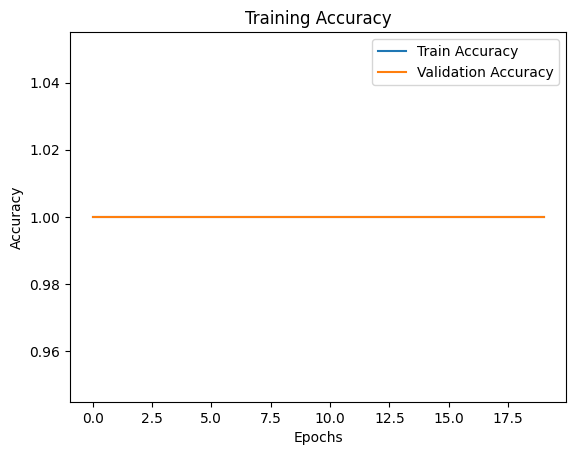

In [29]:
# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy')
plt.show()